In [2]:
import os
import random
import time
import struct
import shutil
from pathlib import Path


NUM_RECORDS = 100_000
RECORD_SIZE_RANGE = (1024, 2048) 
CHUNK_SIZE = 1000
RANDOM_SEED = 42
BASE_DIR = Path("./storage_test")

random.seed(RANDOM_SEED)

def reset_storage():
    if BASE_DIR.exists():
        shutil.rmtree(BASE_DIR)
    BASE_DIR.mkdir()

def generate_records():
    return [os.urandom(random.randint(*RECORD_SIZE_RANGE)) for _ in range(NUM_RECORDS)]

# Benchmark wrapper
def benchmark(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        elapsed = end - start
        count = kwargs.get('read_count', NUM_RECORDS)
        print(f"{func.__name__}: {elapsed:.3f}s total, {(elapsed / count * 1000):.3f} ms/record")
        return result
    return wrapper

# Single
class SingleLargeFile:
    def __init__(self):
        self.file_path = BASE_DIR / "single_storage.dat"
        self.index = []

    @benchmark
    def write(self, records):
        with open(self.file_path, 'wb') as f:
            for record in records:
                offset = f.tell()
                f.write(record)
                self.index.append((offset, len(record)))

    @benchmark
    def read_sequential(self):
        with open(self.file_path, 'rb') as f:
            for offset, size in self.index:
                f.seek(offset)
                _ = f.read(size)

    @benchmark
    def read_random(self, read_count=1000):
        with open(self.file_path, 'rb') as f:
            indices = random.sample(range(NUM_RECORDS), read_count)
            for idx in indices:
                offset, size = self.index[idx]
                f.seek(offset)
                _ = f.read(size)

# Chunked
class ChunkedFiles:
    def __init__(self):
        self.dir = BASE_DIR / "chunked"
        self.dir.mkdir()
        self.index = {}

    @benchmark
    def write(self, records):
        for i in range(0, NUM_RECORDS, CHUNK_SIZE):
            chunk = records[i:i+CHUNK_SIZE]
            file_path = self.dir / f"chunk_{i // CHUNK_SIZE:03d}.dat"
            offsets = []
            with open(file_path, 'wb') as f:
                for rec in chunk:
                    offset = f.tell()
                    f.write(rec)
                    offsets.append((offset, len(rec)))
            self.index[file_path] = offsets

    @benchmark
    def read_sequential(self):
        for file_path, offsets in self.index.items():
            with open(file_path, 'rb') as f:
                for offset, size in offsets:
                    f.seek(offset)
                    _ = f.read(size)

    @benchmark
    def read_random(self, read_count=1000):
        flat_index = []
        for file_path, offsets in self.index.items():
            for i, (offset, size) in enumerate(offsets):
                flat_index.append((file_path, offset, size))
        samples = random.sample(flat_index, read_count)
        for file_path, offset, size in samples:
            with open(file_path, 'rb') as f:
                f.seek(offset)
                _ = f.read(size)

# Individual
class IndividualFiles:
    def __init__(self):
        self.dir = BASE_DIR / "individual"
        self.dir.mkdir()

    @benchmark
    def write(self, records):
        for i, rec in enumerate(records):
            with open(self.dir / f"record_{i:06d}.dat", 'wb') as f:
                f.write(rec)

    @benchmark
    def read_sequential(self):
        for i in range(NUM_RECORDS):
            with open(self.dir / f"record_{i:06d}.dat", 'rb') as f:
                _ = f.read()

    @benchmark
    def read_random(self, read_count=1000):
        indices = random.sample(range(NUM_RECORDS), read_count)
        for i in indices:
            with open(self.dir / f"record_{i:06d}.dat", 'rb') as f:
                _ = f.read()

if __name__ == '__main__':
    reset_storage()
    records = generate_records()

    print("Single Large Files :")
    slf = SingleLargeFile()
    slf.write(records)
    slf.read_sequential()
    slf.read_random()

    print("Chunked Files :")
    cf = ChunkedFiles()
    cf.write(records)
    cf.read_sequential()
    cf.read_random()

    print("Individual Files :")
    ind = IndividualFiles()
    ind.write(records)
    ind.read_sequential()
    ind.read_random()


Single Large Files :
write: 0.457s total, 0.005 ms/record
read_sequential: 0.132s total, 0.001 ms/record
read_random: 0.007s total, 0.000 ms/record
Chunked Files :
write: 0.512s total, 0.005 ms/record
read_sequential: 0.138s total, 0.001 ms/record
read_random: 0.111s total, 0.001 ms/record
Individual Files :
write: 5.804s total, 0.058 ms/record
read_sequential: 3.562s total, 0.036 ms/record
read_random: 0.034s total, 0.000 ms/record


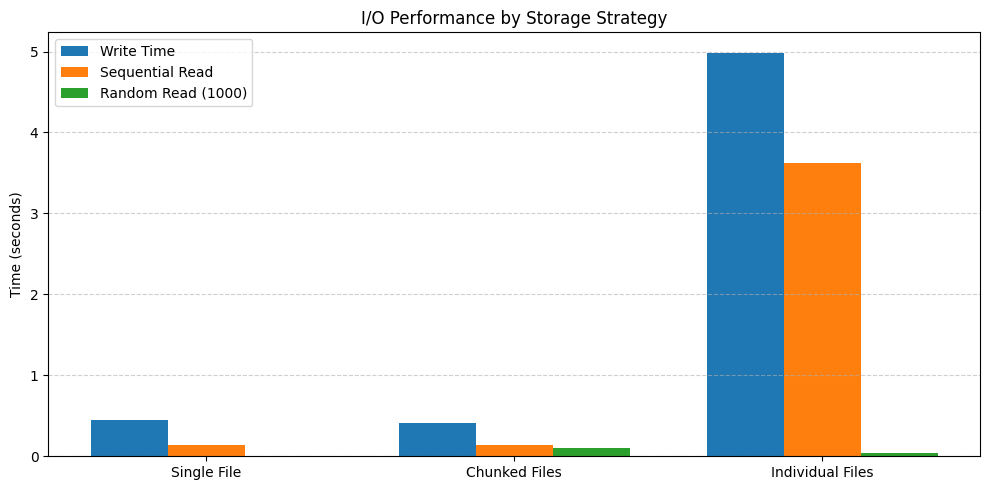

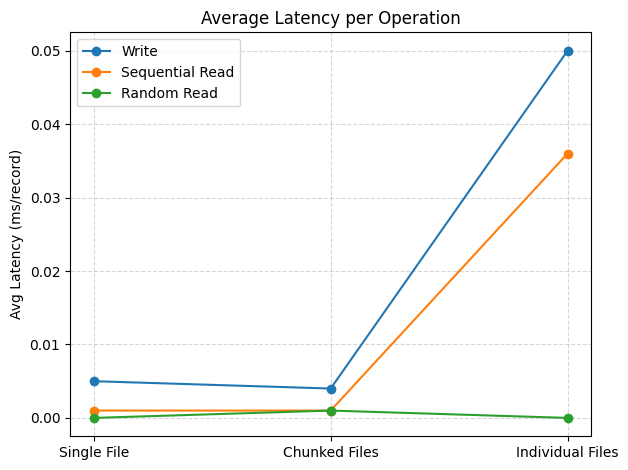

In [6]:
import matplotlib.pyplot as plt

strategies = ['Single File', 'Chunked Files', 'Individual Files']
write_times = [0.453, 0.410, 4.988]
seq_read_times = [0.143, 0.143, 3.628]
rand_read_times = [0.007, 0.098, 0.036]

x = range(len(strategies))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar([i - width for i in x], write_times, width=width, label='Write Time')
plt.bar(x, seq_read_times, width=width, label='Sequential Read')
plt.bar([i + width for i in x], rand_read_times, width=width, label='Random Read (1000)')

plt.xticks(x, strategies)
plt.ylabel('Time (seconds)')
plt.title('I/O Performance by Storage Strategy')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
latencies = {
    'Write': [0.005, 0.004, 0.050],
    'Sequential Read': [0.001, 0.001, 0.036],
    'Random Read': [0.000, 0.001, 0.000]
}

for label, values in latencies.items():
    plt.plot(strategies, values, marker='o', label=label)

plt.ylabel('Avg Latency (ms/record)')
plt.title('Average Latency per Operation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()